In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r'E:\E-commerce Analysis\Data\processed\fato_pedidos_tratada.csv'
df = pd.read_csv(path)

In [3]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_status,customer_state,total_payment
0,5eca2113141f2c0e048b11bdcb7a0371,aa1fd99d3fa9ef872384623522665eb2,2018-01-07 15:20:44,delivered,SP,41.169998
1,85be7c94bcd3f908fc877157ee21f755,54b307e9a6121f572faef4f220fbac3a,2017-09-21 22:00:36,delivered,SP,72.750000
2,a0ce637ae9c3e3dedcf9dea3715b7331,a18e4956844fab232555e2bfd53eca5e,2018-06-27 14:04:06,delivered,PA,143.039993
3,a082f140d70dd20b4e2d7538557b5946,5d8f7d35350a0802b7e4bea9671b132a,2017-03-31 22:28:39,delivered,ES,127.900002
4,c152d21bf4fc58f89b8644af56cdc116,225c0949be781e5efb085b4dacb0a4a8,2018-01-13 13:26:35,delivered,SP,162.550003


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  99441 non-null  str    
 1   customer_id               99441 non-null  str    
 2   order_purchase_timestamp  99441 non-null  str    
 3   order_status              99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   total_payment             99441 non-null  float64
dtypes: float64(1), str(5)
memory usage: 4.6 MB


In [5]:
pd.options.display.float_format = '{:,.2f}'.format

In [6]:
df['order_purchase_timestamp'] = df['order_purchase_timestamp'].astype('datetime64[ns]')

In [7]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_status,customer_state,total_payment
0,5eca2113141f2c0e048b11bdcb7a0371,aa1fd99d3fa9ef872384623522665eb2,2018-01-07 15:20:44,delivered,SP,41.17
1,85be7c94bcd3f908fc877157ee21f755,54b307e9a6121f572faef4f220fbac3a,2017-09-21 22:00:36,delivered,SP,72.75
2,a0ce637ae9c3e3dedcf9dea3715b7331,a18e4956844fab232555e2bfd53eca5e,2018-06-27 14:04:06,delivered,PA,143.04
3,a082f140d70dd20b4e2d7538557b5946,5d8f7d35350a0802b7e4bea9671b132a,2017-03-31 22:28:39,delivered,ES,127.90
4,c152d21bf4fc58f89b8644af56cdc116,225c0949be781e5efb085b4dacb0a4a8,2018-01-13 13:26:35,delivered,SP,162.55


In [8]:
#Faturamento total Vendas
faturamento_total = df['total_payment'].sum()
print(f"{faturamento_total:,.2f}")

16,008,872.12


In [9]:
#Número de Pedidos
numero_pedidos = df['order_id'].count()
print(numero_pedidos)

99441


In [10]:
#Ticket Médio
ticket_medio = faturamento_total / numero_pedidos
print(f"{ticket_medio:,.2f}")

160.99


In [12]:
#Receita por estado
receita_por_estado = df.groupby('customer_state')['total_payment'].sum().sort_values(ascending=False)
print(receita_por_estado)

customer_state
SP   5,998,226.96
RJ   2,144,379.69
MG   1,872,257.26
RS     890,898.54
PR     811,156.38
SC     623,086.43
BA     616,645.82
DF     355,141.08
GO     350,092.31
ES     325,967.55
PE     324,850.44
CE     279,464.03
PA     218,295.85
MT     187,029.29
MA     152,523.02
PB     141,545.72
MS     137,534.84
PI     108,523.97
RN     102,718.13
AL      96,962.06
SE      75,246.25
TO      61,485.33
RO      60,866.20
AM      27,966.93
AC      19,680.62
AP      16,262.80
RR      10,064.62
Name: total_payment, dtype: float64


In [ ]:
#Quantidade Vendida por Estado
quantidade_vendida_estado = df.groupby('customer_state')['order_id'].count().sort_values(ascending=False)
print(quantidade_vendida_estado)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: order_id, dtype: int64


In [22]:
#Ticket Médio por Estado
ticket_medio_estado = receita_por_estado / quantidade_vendida_estado
print(ticket_medio_estado.sort_values(ascending=False))

customer_state
PB   264.08
AC   242.97
RO   240.58
AP   239.16
AL   234.77
PA   223.89
TO   219.59
PI   219.24
RR   218.80
SE   214.99
RN   211.79
CE   209.18
MT   206.21
MA   204.18
PE   196.64
MS   192.36
AM   188.97
BA   182.44
GO   173.31
SC   171.32
RJ   166.85
DF   165.95
RS   162.99
MG   160.92
PR   160.78
ES   160.34
SP   143.68
dtype: float64


In [15]:
df.describe()

,order_purchase_timestamp,total_payment
count,99441,"99,441.00"
mean,2017-12-31 08:43:12.776580864,160.99
min,2016-09-04 21:15:19,0.00
25%,2017-09-12 14:46:19,62.01
50%,2018-01-18 23:04:36,105.29
75%,2018-05-04 15:42:16,176.97
max,2018-10-17 17:30:18,"13,664.08"
std,NaN,221.95


In [18]:
#Checando Desvio Padrão e Variância - Alta Variabilidade
df['total_payment'].var()
df['total_payment'].std()
df['total_payment'].mean()
print(f"Variância: {df['total_payment'].var():,.2f}")
print(f"Desvio Padrão: {df['total_payment'].std():,.2f}")
print(f"Média: {df['total_payment'].mean():,.2f}")

Variância: 49,262.13
Desvio Padrão: 221.95
Média: 160.99


In [ ]:
#Coeficiente de Variação - Alta Variabilidade 
cv = 221.95 / 160.99
print(f"Coeficiente de Variação: {cv:.2f}")

Coeficiente de Variação: 1.38


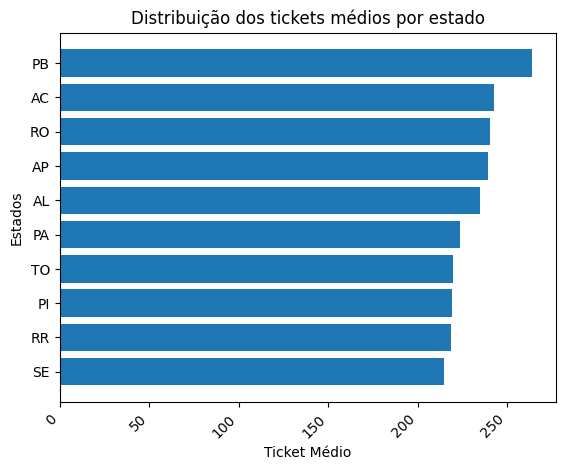

In [23]:
#Distribuição de Ticket Médio
top_estados = ticket_medio_estado.sort_values(ascending=False).head(10)

plt.barh(top_estados.index, top_estados.values)

plt.title("Distribuição dos tickets médios por estado")
plt.xlabel("Ticket Médio")
plt.ylabel("Estados")

plt.xticks(rotation=45, ha='right')

plt.gca().invert_yaxis()

plt.show()


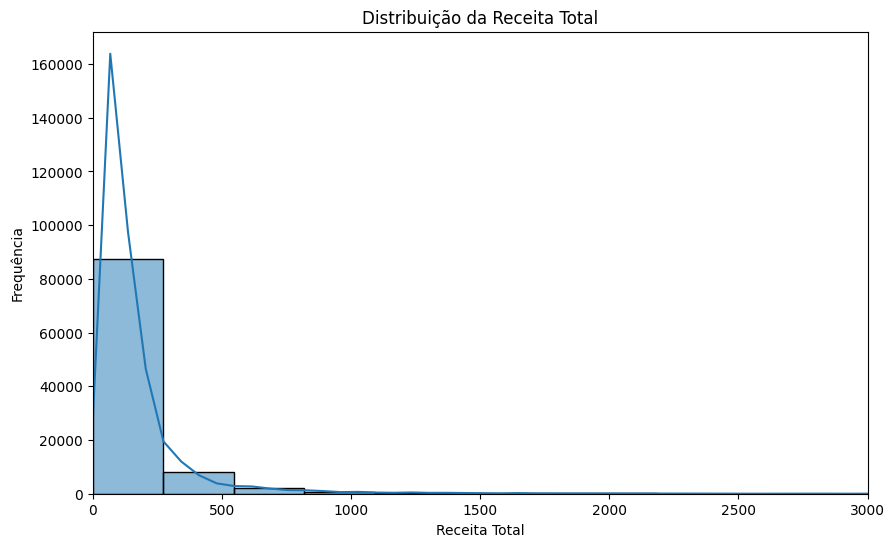

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(df['total_payment'], bins=50, kde=True)
plt.xlim(0, 3000)
plt.title("Distribuição da Receita Total")
plt.xlabel("Receita Total")
plt.ylabel("Frequência")
plt.show()

<Axes: xlabel='total_payment'>

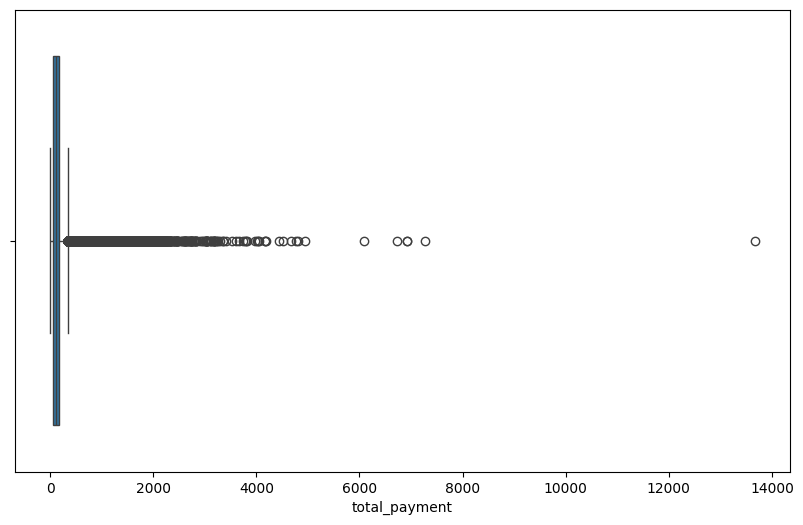

In [29]:
#Boxplot Receita total
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['total_payment'])